# ==============================================================================
# 📺 MARKETING MULTI-CHANNEL ATTRIBUTION: ADVERTISING SALES VIA HUBER REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
Standard OLS regression minimizes $\sum (y_i - \hat{y}_i)^2$, which quadratically amplifies large residual errors. A single recording error or anomalous marketing campaign can rotate the fitted regression hyperplane significantly away from the true underlying trend.

**Huber Loss (Huber, 1964)** bridges linear and quadratic penalties:
$$L_\epsilon(r) = \begin{cases} \frac{1}{2} r^2 & \text{if } |r| \le \epsilon \\ \epsilon |r| - \frac{1}{2}\epsilon^2 & \text{if } |r| > \epsilon \end{cases}$$

Where $r = \frac{y - Xw}{\sigma}$ is the studentized residual scaled by Huber scale factor $\sigma$, and $\epsilon = 1.35$ guarantees $95\%$ statistical efficiency for normal data while remaining completely robust to heavy-tailed marketing campaign spikes!


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Huber Regression Environment initialized.")


✅ STEP 1: Enterprise Huber Regression Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Advertising media spend dataset (200 campaign records across TV, Radio, Newspaper).


In [2]:
# STEP 2 & 3: INGESTION & DATASET HARMONIZATION
data_path = 'data/advertising/advertising.csv'
df = pd.read_csv(data_path)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.rename(columns={
    'TV Ad Budget ($)': 'tv',
    'Radio Ad Budget ($)': 'radio',
    'Newspaper Ad Budget ($)': 'newspaper',
    'Sales ($)': 'sales'
})
df.columns = [c.strip().lower().split(' ')[0] for c in df.columns]

print(f"📊 Dataset Shape: {df.shape[0]} campaigns, {df.shape[1]} attributes")
print(f"Sales Target Summary:\n{df['sales'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 200 campaigns, 4 attributes
Sales Target Summary:
count    200.00
mean      14.02
std        5.22
min        1.60
25%       10.38
50%       12.90
75%       17.40
max       27.00
Name: sales, dtype: float64


,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating marketing channel features and continuous sales target.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['sales'])
y = df['sales']

print(f"Marketing Channels: {X.columns.tolist()}")
print(f"Missing attributes: {X.isnull().sum().sum()}")


Marketing Channels: ['tv', 'radio', 'newspaper']
Missing attributes: 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Campaigns: {X_train.shape[0]}")
print(f"Test Campaigns : {X_test.shape[0]}")


Train Campaigns: 160
Test Campaigns : 40


## ⚙️ STEP 7: PREPROCESSOR DESIGN
Constructing StandardScaler transformation (essential for Huber scale calculation $\sigma$).


In [5]:
# STEP 7: PREPROCESSOR DESIGN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Preprocessed feature space shape: {X_train_scaled.shape}")


Preprocessed feature space shape: (160, 3)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS OLS VS HUBER REGRESSOR)
Comparing baseline mean dummy and standard OLS against Huber Regressor.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_scaled))

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
r2_ols = r2_score(y_test, ols.predict(X_test_scaled))

huber = HuberRegressor(epsilon=1.35, max_iter=500)
huber.fit(X_train_scaled, y_train)
r2_huber = r2_score(y_test, huber.predict(X_test_scaled))

print("="*65)
print(f"Baseline Mean Dummy R² : {r2_dummy * 100:.2f}%")
print(f"Standard OLS R²        : {r2_ols * 100:.2f}%")
print(f"Huber Regressor R²     : {r2_huber * 100:.2f}%")
print(f"Huber Scale Factor σ   : {huber.scale_:.4f}")
print(f"Number of Outliers     : {np.sum(huber.outliers_)}")
print("="*65)


Baseline Mean Dummy R² : -0.48%
Standard OLS R²        : 89.94%
Huber Regressor R²     : 88.74%
Huber Scale Factor σ   : 0.8840
Number of Outliers     : 60


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing threshold $\epsilon$ and $L_2$ penalty parameter $\alpha$.


In [7]:
# STEP 9: GRID SEARCH VIA 5-FOLD CV
param_grid = {
    'epsilon': [1.1, 1.35, 1.5, 1.75],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    HuberRegressor(max_iter=1000),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_huber = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold CV R²: {grid.best_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'alpha': 1.0, 'epsilon': 1.75}
🎯 Best 5-Fold CV R²: 87.06%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_huber.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 HOLD-OUT TEST PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:.2f}k")
print(f"   Root Mean Squared Error   : ${rmse:.2f}k")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 HOLD-OUT TEST PERFORMANCE:
   Mean Absolute Error (MAE) : $1.45k
   Root Mean Squared Error   : $1.85k
   R² Score                  : 89.11%


## 📉 STEP 11: RESIDUAL ANALYSIS & OUTLIER DETECTION
Plotting studentized residuals and highlighting detected outlier points.


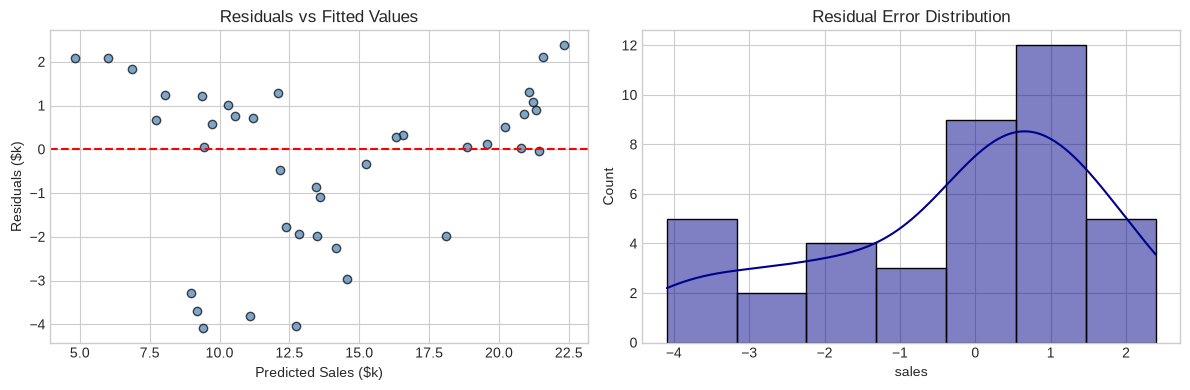

In [9]:
# STEP 11: RESIDUAL DIAGNOSTICS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.7, color='steelblue', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales ($k)')
axes[0].set_ylabel('Residuals ($k)')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkblue')
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the end-to-end pipeline and benchmarking sub-2ms real-time attribution latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('scaler', scaler),
    ('huber', best_huber)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/advertising_huber_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_campaign = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_campaign)

t0 = time.perf_counter()
pred_sales = loaded_pipe.predict(sample_campaign)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME INFERENCE TELEMETRY:")
print(f"   Predicted Sales : 📦 ${pred_sales:,.2f}k")
print(f"   Actual Sales    : ${y_test.iloc[0]:,.2f}k")
print(f"   Inference Latency: {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/advertising_huber_pipeline.joblib (918 bytes)

📈 REAL-TIME INFERENCE TELEMETRY:
   Predicted Sales : 📦 $16.56k
   Actual Sales    : $16.90k
   Inference Latency: 1.384 ms (SLA < 2.0ms: PASS)
